In [ ]:
import docker
docker_client = docker.from_env()
img = docker_client.images.pull(
            "ghcr.io/becksteinlab/streaming-md-docker:main-Common-CPU"
        )

container = docker_client.containers.run(
            img,
            f"/bin/sh -c 'cd /tmp && ./run.sh'",
            detach=True,
            volumes={"/nfs/homes3/ljwoods2/workspace/imd-workshop-2024/gromacs-demos/distances": {"bind": "/tmp", "mode": "rw"}},
            ports={"8888/tcp": 8888},
            name="sim",
            remove=True,
        )

In [1]:
import MDAnalysis as mda
#from MDAnalysis.lib.correlations import autocorrelation
import MDAnalysis.analysis.base as mda_base

import numpy as np

import vdos as vd

import matplotlib.pyplot as plt
from IPython.display import display, clear_output

/etc/python/sitecustomize.py:117: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  mod = _original_import(name, globals, locals, fromlist, level)


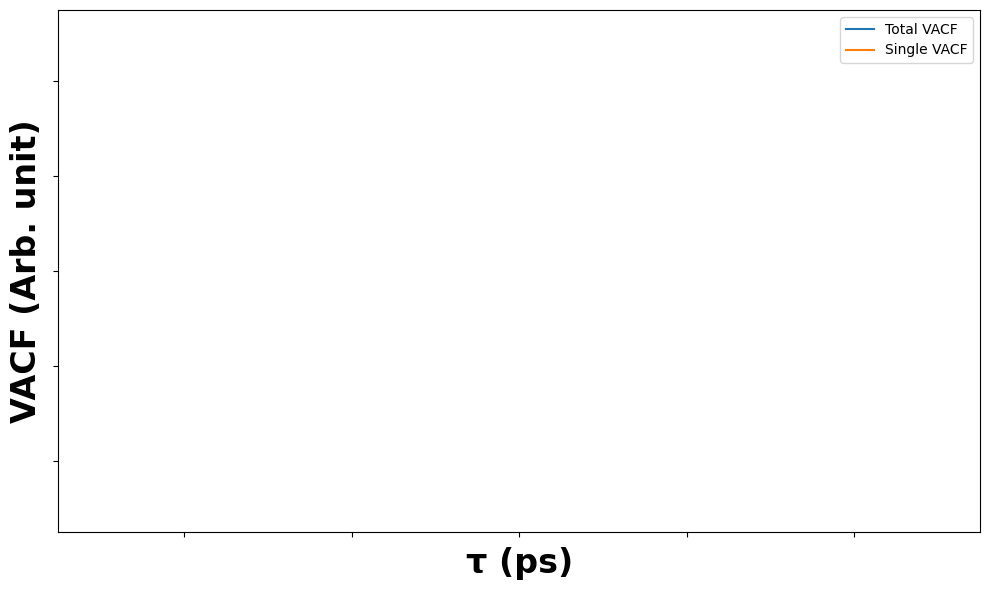

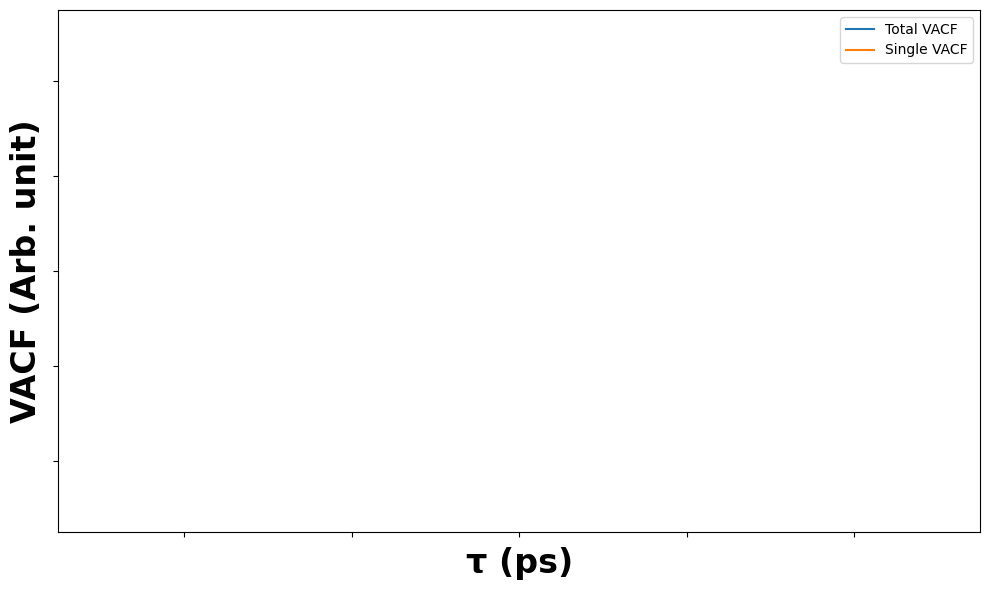

In [2]:
plt.ion()
fig, ax = plt.subplots(figsize=(10, 6))
p_total, = ax.plot([], [], label='Total VACF')
p_single, = ax.plot([], [], label='Single VACF')
ax.set_xlabel('τ (ps)', fontsize=24, fontweight='bold',color='black')
ax.set_ylabel('VACF (Arb. unit)', fontsize=24, fontweight='bold',color='black')
ax.set_xticklabels([])
ax.set_yticklabels([])
#ax.set_xlim(0, 1000)
#ax.set_ylim(0, 12000)
plt.tight_layout()
ax.legend()
display(fig)  # Display the figure initially

In [ ]:
try:
    # Connect to IMD server
    u = mda.Universe("mda.tpr", "imd://localhost:8894")
    sel = u.select_atoms("resname SOL")
    vdos = vd.vdos(sel, 200)
    vd.vdosLib.omp_set_num_threads(4)
except Exception as e:
    print(f"Error during connection: {e}")
else:
    try:
        tStep = 0
        
        for ts in u.trajectory:            
            # Process frame using VDOS
            vdos.single_frame(tStep, ts.time)
            
            # Update plot every 200 steps
            if tStep % 200 == 0:
                vdos.copyResidueList()
                vdos.postProcess(vdos.residueListCopy, mode="total+single")

                
                time_axis = np.array(vdos.tau)
                vacf_total = np.array(vdos.totVACF[0])
                vacf_single = np.array(vdos.totVACF[1])

                # update lines
                p_total.set_data(time_axis, vacf_total)
                p_single.set_data(time_axis, vacf_single)
                
                ax.relim()  # Recompute limits
                ax.autoscale_view()  # Autoscale the view
                
                clear_output(wait=True)
                display(fig)
            
            tStep += 1
            
    finally:
        u.trajectory.close()

plt.ioff()  # Turn off interactive mode when done

Error during connection: Failed to construct topology from file imd/topol.tpr with parser <class 'MDAnalysis.topology.TPRParser.TPRParser'>.
Error: Your tpx version is 136, which this parser does not support, yet 
